# Two-Model Grad-CAM vs Native-CAM Comparison

This evaluation-only notebook compares **final-layer Grad-CAM** with the deployed
**native class activation map** for the same DenseNet-121 and SE-ResNeXt50-32x4d checkpoints. It does not train or change any model.

The comparison is controlled: every method uses the same checkpoint, validation
image, preprocessing, target class, final feature tensor, output resolution, and
anatomical masks. The test split is not read.

Important interpretation: with a linear 1x1 class head and global average pooling,
Grad-CAM uses the same class weights as bias-free CAM. The current native map also
contains the learned class bias, which is spatially uniform. Therefore, these two
methods may be identical or differ only because native CAM retains this class-prior
term. The quantitative experiment decides; visual appearance alone does not.


## Run Instructions

Run every cell from top to bottom after the two selected `best_model.pth` files
exist in Google Drive. DenseNet and SE-ResNeXt are pinned to their production run
timestamps. EfficientNet is intentionally skipped because no selected checkpoint
is available.

The notebook evaluates up to 50 validation images per KL grade, writes all artifacts
under a new UTC-timestamped directory, and releases the Colab runtime at the end.


In [3]:
import csv
import gc
import hashlib
import json
import random
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

try:
    import timm
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "timm"],
        check=True,
    )
    import timm

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import tqdm
from torch.utils.data import Dataset
from torchvision import models

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

SEED = 42
AUDIT_PER_GRADE = 50
OCCLUSION_GRID = 4
BOOTSTRAP_REPETITIONS = 2000
EQUIVALENCE_MAX_ABS_TOLERANCE = 1e-5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

dataset_zip = Path(
    "/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip"
)
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime(
    "%Y-%m-%d_%H-%M-%S_%f_UTC"
)
RUN_DIR = (
    Path("/content/drive/MyDrive/Models/cam_method_comparisons")
    / f"{RUN_TIMESTAMP}_two_model_gradcam_vs_native_cam"
)
RUN_DIR.mkdir(parents=True, exist_ok=False)
print(f"Output directory: {RUN_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
Output directory: /content/drive/MyDrive/Models/cam_method_comparisons/2026-07-24_01-12-36_714882_UTC_two_model_gradcam_vs_native_cam


## Checkpoint Resolution

Resolution uses checkpoint metadata rather than folder sorting alone. This prevents
the rejected SE-ResNeXt multiscale/EMA checkpoint or an older DenseNet architecture
from entering the comparison accidentally. The cell fails clearly when a required
checkpoint is absent or ambiguous.


In [4]:
MODEL_SPECS = {
    "densenet121": {
        "model_name": "densenet121",
        "architecture": "canonical_final_linear_cam",
        "run_timestamp": "2026-07-23_01-31-37_184239_UTC",
        "roots": [
            Path("/content/drive/MyDrive/Models/densenet121_checkpoints"),
            Path("/home/viet/Capstone/ml/checkpoints/densenet121"),
        ],
    },
    "seresnext50_32x4d": {
        "model_name": "seresnext50_32x4d",
        "architecture": "final_native_cam_ce",
        "run_timestamp": "2026-07-23_01-25-36_772175_UTC",
        "roots": [
            Path("/content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints"),
            Path("/home/viet/Capstone/ml/checkpoints/se_resnext50_32x4d"),
        ],
    },
}


def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def checkpoint_matches(payload, spec):
    if not isinstance(payload, dict) or "model_state_dict" not in payload:
        return False
    if payload.get("model_name") != spec["model_name"]:
        return False
    if payload.get("architecture") != spec["architecture"]:
        return False
    expected_timestamp = spec["run_timestamp"]
    return expected_timestamp is None or payload.get("run_timestamp") == expected_timestamp


def resolve_checkpoint(spec):
    matches = []
    for root in spec["roots"]:
        if not root.exists():
            continue
        for path in sorted(root.rglob("*.pth")):
            if "best_model" not in path.name:
                continue
            try:
                payload = load_checkpoint(path)
            except Exception as error:
                print(f"Skipping unreadable checkpoint {path}: {error}")
                continue
            if checkpoint_matches(payload, spec):
                matches.append((str(payload.get("run_timestamp", "")), path, payload))
    if not matches:
        raise FileNotFoundError(
            "No matching checkpoint for "
            f"model={spec['model_name']}, architecture={spec['architecture']}, "
            f"timestamp={spec['run_timestamp']}."
        )
    matches.sort(key=lambda item: (item[0], str(item[1])))
    selected_timestamp, selected_path, selected_payload = matches[-1]
    print(
        f"{spec['model_name']}: {selected_path} "
        f"({selected_timestamp}, {spec['architecture']})"
    )
    return selected_path, selected_payload


resolved_checkpoints = {
    name: resolve_checkpoint(spec) for name, spec in MODEL_SPECS.items()
}


densenet121: /content/drive/MyDrive/Models/densenet121_checkpoints/archive/2026-07-23_01-31-37_184239_UTC_canonical_final_linear_cam_production/stage2_best_model.pth (2026-07-23_01-31-37_184239_UTC, canonical_final_linear_cam)
seresnext50_32x4d: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-23_01-25-36_772175_UTC_final_native_cam_ce/stage2_best_model.pth (2026-07-23_01-25-36_772175_UTC, final_native_cam_ce)


## Validation Images and Identical Preprocessing

Right knees are mirrored to the same orientation as left knees. Validation uses the
same square padding, CLAHE, resize-400, center-crop-384, and ImageNet normalization
as the selected model runs. Exact train duplicates are excluded by SHA-256. No data
augmentation and no test images are used.


In [5]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0],
        )


class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=2.0, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


evaluation_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.Resize((400, 400)),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def collect_split_hashes(split):
    hashes = set()
    for grade in range(5):
        grade_dir = DATASET_ROOT / split / str(grade)
        if not grade_dir.is_dir():
            raise FileNotFoundError(f"Dataset grade directory is missing: {grade_dir}")
        for path in sorted(grade_dir.iterdir()):
            if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
                hashes.add(file_digest(path))
    return hashes


class KneeValidationDataset(Dataset):
    def __init__(self, excluded_hashes):
        self.paths = []
        self.labels = []
        retained_hashes = set()
        for grade in range(5):
            grade_dir = DATASET_ROOT / "val" / str(grade)
            for path in sorted(grade_dir.iterdir()):
                if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                digest = file_digest(path)
                if digest in excluded_hashes or digest in retained_hashes:
                    continue
                retained_hashes.add(digest)
                self.paths.append(str(path))
                self.labels.append(grade)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if Path(path).stem.upper().endswith("R"):
            image = np.ascontiguousarray(image[:, ::-1])
        return evaluation_transform(image), self.labels[index], path


validation_dataset = KneeValidationDataset(collect_split_hashes("train"))
labels_array = np.asarray(validation_dataset.labels)
rng = np.random.default_rng(SEED)
audit_indices = []
for grade in range(5):
    indices = np.flatnonzero(labels_array == grade)
    rng.shuffle(indices)
    audit_indices.extend(indices[: min(AUDIT_PER_GRADE, len(indices))].tolist())
print(f"Validation images: {len(validation_dataset)}")
print(f"Controlled audit images: {len(audit_indices)}")
print({grade: int(np.sum(labels_array[audit_indices] == grade)) for grade in range(5)})


Validation images: 826
Controlled audit images: 227
{0: 50, 1: 50, 2: 50, 3: 50, 4: 27}


## Common Linear Native-CAM Models

Both wrappers expose the final convolutional features and a five-channel 1x1
class head. Logits are exactly the spatial means of those five maps. Grad-CAM is
computed directly with `torch.autograd.grad`; no persistent hooks are installed,
which avoids stale activations and `retain_grad()` failures inside `no_grad()`.


In [6]:
class LinearNativeCAMModel(nn.Module):
    def feature_maps(self, images):
        raise NotImplementedError

    def class_maps_from_features(self, features):
        return self.class_conv(features)

    def forward(self, images):
        class_maps = self.class_maps_from_features(self.feature_maps(images))
        return class_maps.mean(dim=(2, 3))


class DenseNet121NativeCAM(LinearNativeCAMModel):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "densenet121", pretrained=False, features_only=True, out_indices=(4,)
        )
        self.class_conv = nn.Conv2d(
            self.backbone.feature_info.channels()[0], 5, kernel_size=1
        )

    def feature_maps(self, images):
        return self.backbone(images)[0]


class SEResNeXt50NativeCAM(LinearNativeCAMModel):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "seresnext50_32x4d",
            pretrained=False,
            features_only=True,
            out_indices=(4,),
        )
        self.class_conv = nn.Conv2d(
            self.backbone.feature_info.channels()[0], 5, kernel_size=1
        )

    def feature_maps(self, images):
        return self.backbone(images)[0]


MODEL_FACTORIES = {
    "densenet121": DenseNet121NativeCAM,
    "seresnext50_32x4d": SEResNeXt50NativeCAM,
}


def normalized_positive_map(source_map, output_size):
    cam = F.relu(source_map)[None, None]
    cam = F.interpolate(
        cam,
        size=output_size,
        mode="bilinear",
        align_corners=False,
    )[0, 0]
    return cam / cam.max().clamp_min(1e-8)


def explain_native_and_gradcam(model, image, target_class):
    model.zero_grad(set_to_none=True)
    features = model.feature_maps(image)
    class_maps = model.class_maps_from_features(features)
    logits = class_maps.mean(dim=(2, 3))
    target_score = logits[0, target_class]
    gradients = torch.autograd.grad(
        target_score, features, retain_graph=False, create_graph=False
    )[0]
    gradcam_weights = gradients.mean(dim=(2, 3), keepdim=True)
    gradcam_source = (gradcam_weights * features).sum(dim=1)[0]
    bias_free_source = (
        model.class_conv.weight[target_class, :, 0, 0][None, :, None, None]
        * features
    ).sum(dim=1)[0]
    native_source = class_maps[0, target_class]
    output_size = tuple(image.shape[-2:])
    native_cam = normalized_positive_map(native_source, output_size)
    gradcam = normalized_positive_map(gradcam_source, output_size)
    bias_free_cam = normalized_positive_map(bias_free_source, output_size)

    expected_gradient_weights = (
        model.class_conv.weight[target_class, :, 0, 0]
        / (features.shape[-2] * features.shape[-1])
    )
    gradient_weight_error = (
        gradcam_weights[0, :, 0, 0] - expected_gradient_weights
    ).abs().max()
    return {
        "logits": logits.detach(),
        "native": native_cam.detach(),
        "gradcam": gradcam.detach(),
        "bias_free_cam": bias_free_cam.detach(),
        "source_resolution": int(features.shape[-1]),
        "gradient_weight_error": float(gradient_weight_error.detach().cpu()),
        "class_bias": float(model.class_conv.bias[target_class].detach().cpu()),
    }


checkpoint_manifest = {}
for model_name, factory in MODEL_FACTORIES.items():
    checkpoint_path, checkpoint = resolved_checkpoints[model_name]
    checkpoint_manifest[model_name] = {
        "path": str(checkpoint_path),
        "run_timestamp": checkpoint.get("run_timestamp"),
        "architecture": checkpoint.get("architecture"),
        "epoch": checkpoint.get("epoch"),
        "validation_metrics": checkpoint.get("validation_metrics", {}),
    }
print(json.dumps(checkpoint_manifest, indent=2))


{
  "densenet121": {
    "path": "/content/drive/MyDrive/Models/densenet121_checkpoints/archive/2026-07-23_01-31-37_184239_UTC_canonical_final_linear_cam_production/stage2_best_model.pth",
    "run_timestamp": "2026-07-23_01-31-37_184239_UTC",
    "architecture": "canonical_final_linear_cam",
    "epoch": 18,
    "validation_metrics": {
      "accuracy": 0.6464891041162227,
      "qwk": 0.8068579856203528,
      "macro_precision": 0.6747545566699371,
      "macro_recall": 0.6815656747947428,
      "macro_f1": 0.6775398144825704,
      "grade1_recall": 0.37254901960784315,
      "macro_ap": 0.7117646483037132,
      "macro_auc": 0.8809635142115315,
      "selection_score": 0.7144754995410474,
      "loss": 0.8383020649215356
    }
  },
  "seresnext50_32x4d": {
    "path": "/content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-23_01-25-36_772175_UTC_final_native_cam_ce/stage2_best_model.pth",
    "run_timestamp": "2026-07-23_01-25-36_772175_UTC",
    "architecture": "final_

## Paired Localization and Faithfulness Audit

For both methods and the same target class, the notebook records:

- joint-region, border, and lower-tibia energy;
- whether the maximum activation is inside the joint region;
- confidence-drop correlation across a 4x4 occlusion grid;
- mean drop for the four highest-energy grid cells;
- native/Grad-CAM pixel agreement and the analytical Grad-CAM weight error.

Predicted-class maps are evaluated for every audit image. On mistakes, the same
measurements are also produced for the true class. Mean-filled occlusion (`0` after
normalization) is identical for both methods, so differences reflect only cell
ranking/energy, not different perturbed images.


In [7]:
def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint].sum()) / total,
        "border_energy": float(cam[border].sum()) / total,
        "lower_tibia_energy": float(cam[lower_tibia].sum()) / total,
        "peak_inside_joint": int(joint[peak]),
        "anatomy_score": (
            float(cam[joint].sum())
            - float(cam[border].sum())
            - float(cam[lower_tibia].sum())
        ) / total,
    }


def make_occlusion_batch(image, grid_size):
    height, width = image.shape[-2:]
    patch_height = height // grid_size
    patch_width = width // grid_size
    variants = []
    slices = []
    for row in range(grid_size):
        for column in range(grid_size):
            y0 = row * patch_height
            y1 = height if row == grid_size - 1 else (row + 1) * patch_height
            x0 = column * patch_width
            x1 = width if column == grid_size - 1 else (column + 1) * patch_width
            variant = image.clone()
            variant[:, y0:y1, x0:x1] = 0.0
            variants.append(variant)
            slices.append((y0, y1, x0, x1))
    return torch.stack(variants), slices


@torch.no_grad()
def confidence_drops(model, image, target_class, baseline_probability):
    variants, slices = make_occlusion_batch(image, OCCLUSION_GRID)
    probabilities = F.softmax(model(variants.to(device)), dim=1)[:, target_class]
    return (baseline_probability - probabilities).cpu().numpy(), slices


def faithfulness_metrics(cam, drops, slices):
    energies = np.asarray([
        float(cam[y0:y1, x0:x1].sum()) for y0, y1, x0, x1 in slices
    ])
    if np.std(energies) < 1e-8 or np.std(drops) < 1e-8:
        correlation = 0.0
    else:
        correlation = float(np.corrcoef(energies, drops)[0, 1])
    top_count = max(1, len(energies) // 4)
    top_indices = np.argsort(energies)[-top_count:]
    return {
        "occlusion_correlation": correlation,
        "top_cam_confidence_drop": float(np.mean(drops[top_indices])),
    }


audit_rows = []
map_cache = {}
for model_name, factory in MODEL_FACTORIES.items():
    _, checkpoint = resolved_checkpoints[model_name]
    model = factory().to(device)
    state = checkpoint["model_state_dict"]
    if state and all(key.startswith("module.") for key in state):
        state = {key.removeprefix("module."): value for key, value in state.items()}
    model.load_state_dict(state, strict=True)
    model.eval()
    for dataset_index in tqdm.tqdm(
        audit_indices, desc=f"{model_name}: native vs Grad-CAM"
    ):
        tensor, true_grade, path = validation_dataset[dataset_index]
        image = tensor[None].to(device)
        with torch.no_grad():
            initial_logits = model(image)
            probabilities = F.softmax(initial_logits, dim=1)
            predicted_grade = int(probabilities.argmax(1).item())
        target_pairs = [("predicted", predicted_grade)]
        if predicted_grade != int(true_grade):
            target_pairs.append(("true_on_error", int(true_grade)))

        for target_kind, target_class in target_pairs:
            explanation = explain_native_and_gradcam(
                model, image, target_class
            )
            native = explanation["native"].cpu().numpy()
            gradcam = explanation["gradcam"].cpu().numpy()
            bias_free = explanation["bias_free_cam"].cpu().numpy()
            baseline_probability = probabilities[0, target_class]
            drops, slices = confidence_drops(
                model, tensor, target_class, baseline_probability
            )
            agreement = {
                "map_mae": float(np.mean(np.abs(native - gradcam))),
                "map_max_abs_difference": float(np.max(np.abs(native - gradcam))),
                "map_correlation": (
                    0.0
                    if np.std(native) < 1e-8 or np.std(gradcam) < 1e-8
                    else float(np.corrcoef(native.ravel(), gradcam.ravel())[0, 1])
                ),
                "bias_free_gradcam_max_abs_difference": float(
                    np.max(np.abs(bias_free - gradcam))
                ),
            }
            base = {
                "model": model_name,
                "dataset_index": dataset_index,
                "path": path,
                "true_grade": int(true_grade),
                "predicted_grade": predicted_grade,
                "target_kind": target_kind,
                "target_class": target_class,
                "source_resolution": explanation["source_resolution"],
                "target_probability": float(baseline_probability.cpu()),
                "class_bias": explanation["class_bias"],
                "gradient_weight_error": explanation["gradient_weight_error"],
                **agreement,
            }
            for method, cam in (("native_cam", native), ("gradcam", gradcam)):
                audit_rows.append({
                    **base,
                    "method": method,
                    **cam_geometry(cam),
                    **faithfulness_metrics(cam, drops, slices),
                })
            map_cache[(model_name, dataset_index, target_kind)] = (
                tensor, native, gradcam
            )
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

audit_frame = pd.DataFrame(audit_rows)
audit_frame.to_csv(RUN_DIR / "cam_comparison_per_image.csv", index=False)
print(audit_frame.groupby(["model", "target_kind", "method"]).size())


seresnext50_32x4d: native vs Grad-CAM: 100%|██████████| 227/227 [01:21<00:00,  2.79it/s]


model              target_kind    method    
densenet121        predicted      gradcam       227
                                  native_cam    227
                   true_on_error  gradcam        74
                                  native_cam     74
seresnext50_32x4d  predicted      gradcam       227
                                  native_cam    227
                   true_on_error  gradcam        82
                                  native_cam     82
dtype: int64


## Summary, Paired Bootstrap, and Decision Rule

All method comparisons are paired by model, image, and target class. Bootstrap
intervals resample those paired validation cases. Positive deltas favor native CAM
for joint energy, peak-inside rate, anatomy score, occlusion correlation, and top-CAM
confidence drop. Negative deltas favor native CAM for border and lower-tibia energy.

Native CAM is declared superior only if the 95% interval excludes zero in the
favorable direction for both the anatomy score and occlusion correlation. Grad-CAM
uses the symmetric rule. Otherwise the result is `no demonstrated superiority`.
This rule is fixed before reading the experiment results.


In [8]:
PRIMARY_METRICS = [
    "joint_energy",
    "border_energy",
    "lower_tibia_energy",
    "peak_inside_joint",
    "anatomy_score",
    "occlusion_correlation",
    "top_cam_confidence_drop",
]


def paired_metric_frame(frame, metric):
    predicted = frame[frame["target_kind"] == "predicted"]
    return predicted.pivot(
        index=["model", "dataset_index"], columns="method", values=metric
    ).dropna()


def bootstrap_mean_difference(values, repetitions, seed):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    means = np.empty(repetitions, dtype=np.float64)
    for start in range(0, repetitions, 200):
        count = min(200, repetitions - start)
        indices = rng.integers(0, len(values), size=(count, len(values)))
        means[start:start + count] = values[indices].mean(axis=1)
    return (
        float(values.mean()),
        float(np.quantile(means, 0.025)),
        float(np.quantile(means, 0.975)),
    )


summary_rows = []
bootstrap_rows = []
decision_rows = []
for model_index, model_name in enumerate(MODEL_SPECS):
    predicted = audit_frame[
        (audit_frame["model"] == model_name)
        & (audit_frame["target_kind"] == "predicted")
    ]
    for method in ("native_cam", "gradcam"):
        method_frame = predicted[predicted["method"] == method]
        row = {
            "model": model_name,
            "method": method,
            "cases": len(method_frame),
        }
        for metric in PRIMARY_METRICS:
            row[metric] = float(method_frame[metric].mean())
        row["map_mae_vs_other"] = float(method_frame["map_mae"].mean())
        row["map_max_abs_difference"] = float(
            method_frame["map_max_abs_difference"].max()
        )
        row["map_correlation_vs_other"] = float(
            method_frame["map_correlation"].mean()
        )
        row["max_gradient_weight_error"] = float(
            method_frame["gradient_weight_error"].max()
        )
        row["max_bias_free_gradcam_difference"] = float(
            method_frame["bias_free_gradcam_max_abs_difference"].max()
        )
        summary_rows.append(row)

    model_intervals = {}
    for metric_index, metric in enumerate(PRIMARY_METRICS):
        paired = paired_metric_frame(
            audit_frame[audit_frame["model"] == model_name], metric
        )
        differences = paired["native_cam"] - paired["gradcam"]
        mean_delta, lower, upper = bootstrap_mean_difference(
            differences,
            BOOTSTRAP_REPETITIONS,
            SEED + 100 * model_index + metric_index,
        )
        bootstrap_rows.append({
            "model": model_name,
            "metric": metric,
            "native_minus_gradcam": mean_delta,
            "ci95_lower": lower,
            "ci95_upper": upper,
            "paired_cases": len(differences),
        })
        model_intervals[metric] = (lower, upper)

    anatomy_lower, anatomy_upper = model_intervals["anatomy_score"]
    faith_lower, faith_upper = model_intervals["occlusion_correlation"]
    if anatomy_lower > 0 and faith_lower > 0:
        decision = "native_cam_superior"
    elif anatomy_upper < 0 and faith_upper < 0:
        decision = "gradcam_superior"
    else:
        decision = "no_demonstrated_superiority"
    max_difference = float(predicted["map_max_abs_difference"].max())
    decision_rows.append({
        "model": model_name,
        "decision": decision,
        "maps_equivalent_at_tolerance": (
            max_difference <= EQUIVALENCE_MAX_ABS_TOLERANCE
        ),
        "equivalence_tolerance": EQUIVALENCE_MAX_ABS_TOLERANCE,
        "maximum_pixel_difference": max_difference,
    })

summary_frame = pd.DataFrame(summary_rows)
bootstrap_frame = pd.DataFrame(bootstrap_rows)
decision_frame = pd.DataFrame(decision_rows)
summary_frame.to_csv(RUN_DIR / "cam_method_summary.csv", index=False)
bootstrap_frame.to_csv(RUN_DIR / "paired_bootstrap_differences.csv", index=False)
decision_frame.to_csv(RUN_DIR / "method_decisions.csv", index=False)

display(summary_frame.round(5))
display(bootstrap_frame.round(5))
display(decision_frame)


,model,method,cases,joint_energy,border_energy,lower_tibia_energy,peak_inside_joint,anatomy_score,occlusion_correlation,top_cam_confidence_drop,map_mae_vs_other,map_max_abs_difference,map_correlation_vs_other,max_gradient_weight_error,max_bias_free_gradcam_difference
0,densenet121,native_cam,227,0.79972,0.13080,0.10142,1.00000,0.56750,0.71089,0.20954,0.00014,0.00136,1.0,0.0,0.0
1,densenet121,gradcam,227,0.79923,0.13101,0.10170,1.00000,0.56652,0.71095,0.20954,0.00014,0.00136,1.0,0.0,0.0
2,seresnext50_32x4d,native_cam,227,0.86903,0.07690,0.08789,0.99559,0.70425,0.65282,0.18393,0.00008,0.00059,1.0,0.0,0.0
3,seresnext50_32x4d,gradcam,227,0.86920,0.07682,0.08786,0.99559,0.70451,0.65280,0.18393,0.00008,0.00059,1.0,0.0,0.0


,model,metric,native_minus_gradcam,ci95_lower,ci95_upper,paired_cases
0,densenet121,joint_energy,0.00049,0.00039,0.00058,227
1,densenet121,border_energy,-0.00021,-0.00025,-0.00016,227
2,densenet121,lower_tibia_energy,-0.00028,-0.00034,-0.00023,227
3,densenet121,peak_inside_joint,0.00000,0.00000,0.00000,227
4,densenet121,anatomy_score,0.00097,0.00079,0.00117,227
5,densenet121,occlusion_correlation,-0.00007,-0.00009,-0.00004,227
6,densenet121,top_cam_confidence_drop,0.00000,0.00000,0.00000,227
7,seresnext50_32x4d,joint_energy,-0.00016,-0.00026,-0.00006,227
8,seresnext50_32x4d,border_energy,0.00008,0.00004,0.00012,227
9,seresnext50_32x4d,lower_tibia_energy,0.00002,-0.00002,0.00007,227


,model,decision,maps_equivalent_at_tolerance,equivalence_tolerance,maximum_pixel_difference
0,densenet121,no_demonstrated_superiority,False,0.00001,0.001359
1,seresnext50_32x4d,no_demonstrated_superiority,False,0.00001,0.000592


## Side-by-Side Evidence

For each model, the first figure shows the largest native/Grad-CAM disagreements.
The second figure focuses on misclassified knees and shows both predicted-class and
true-class explanations. The cyan rectangle is the fixed joint-region audit mask;
it is a measurement guide, not a ground-truth segmentation.


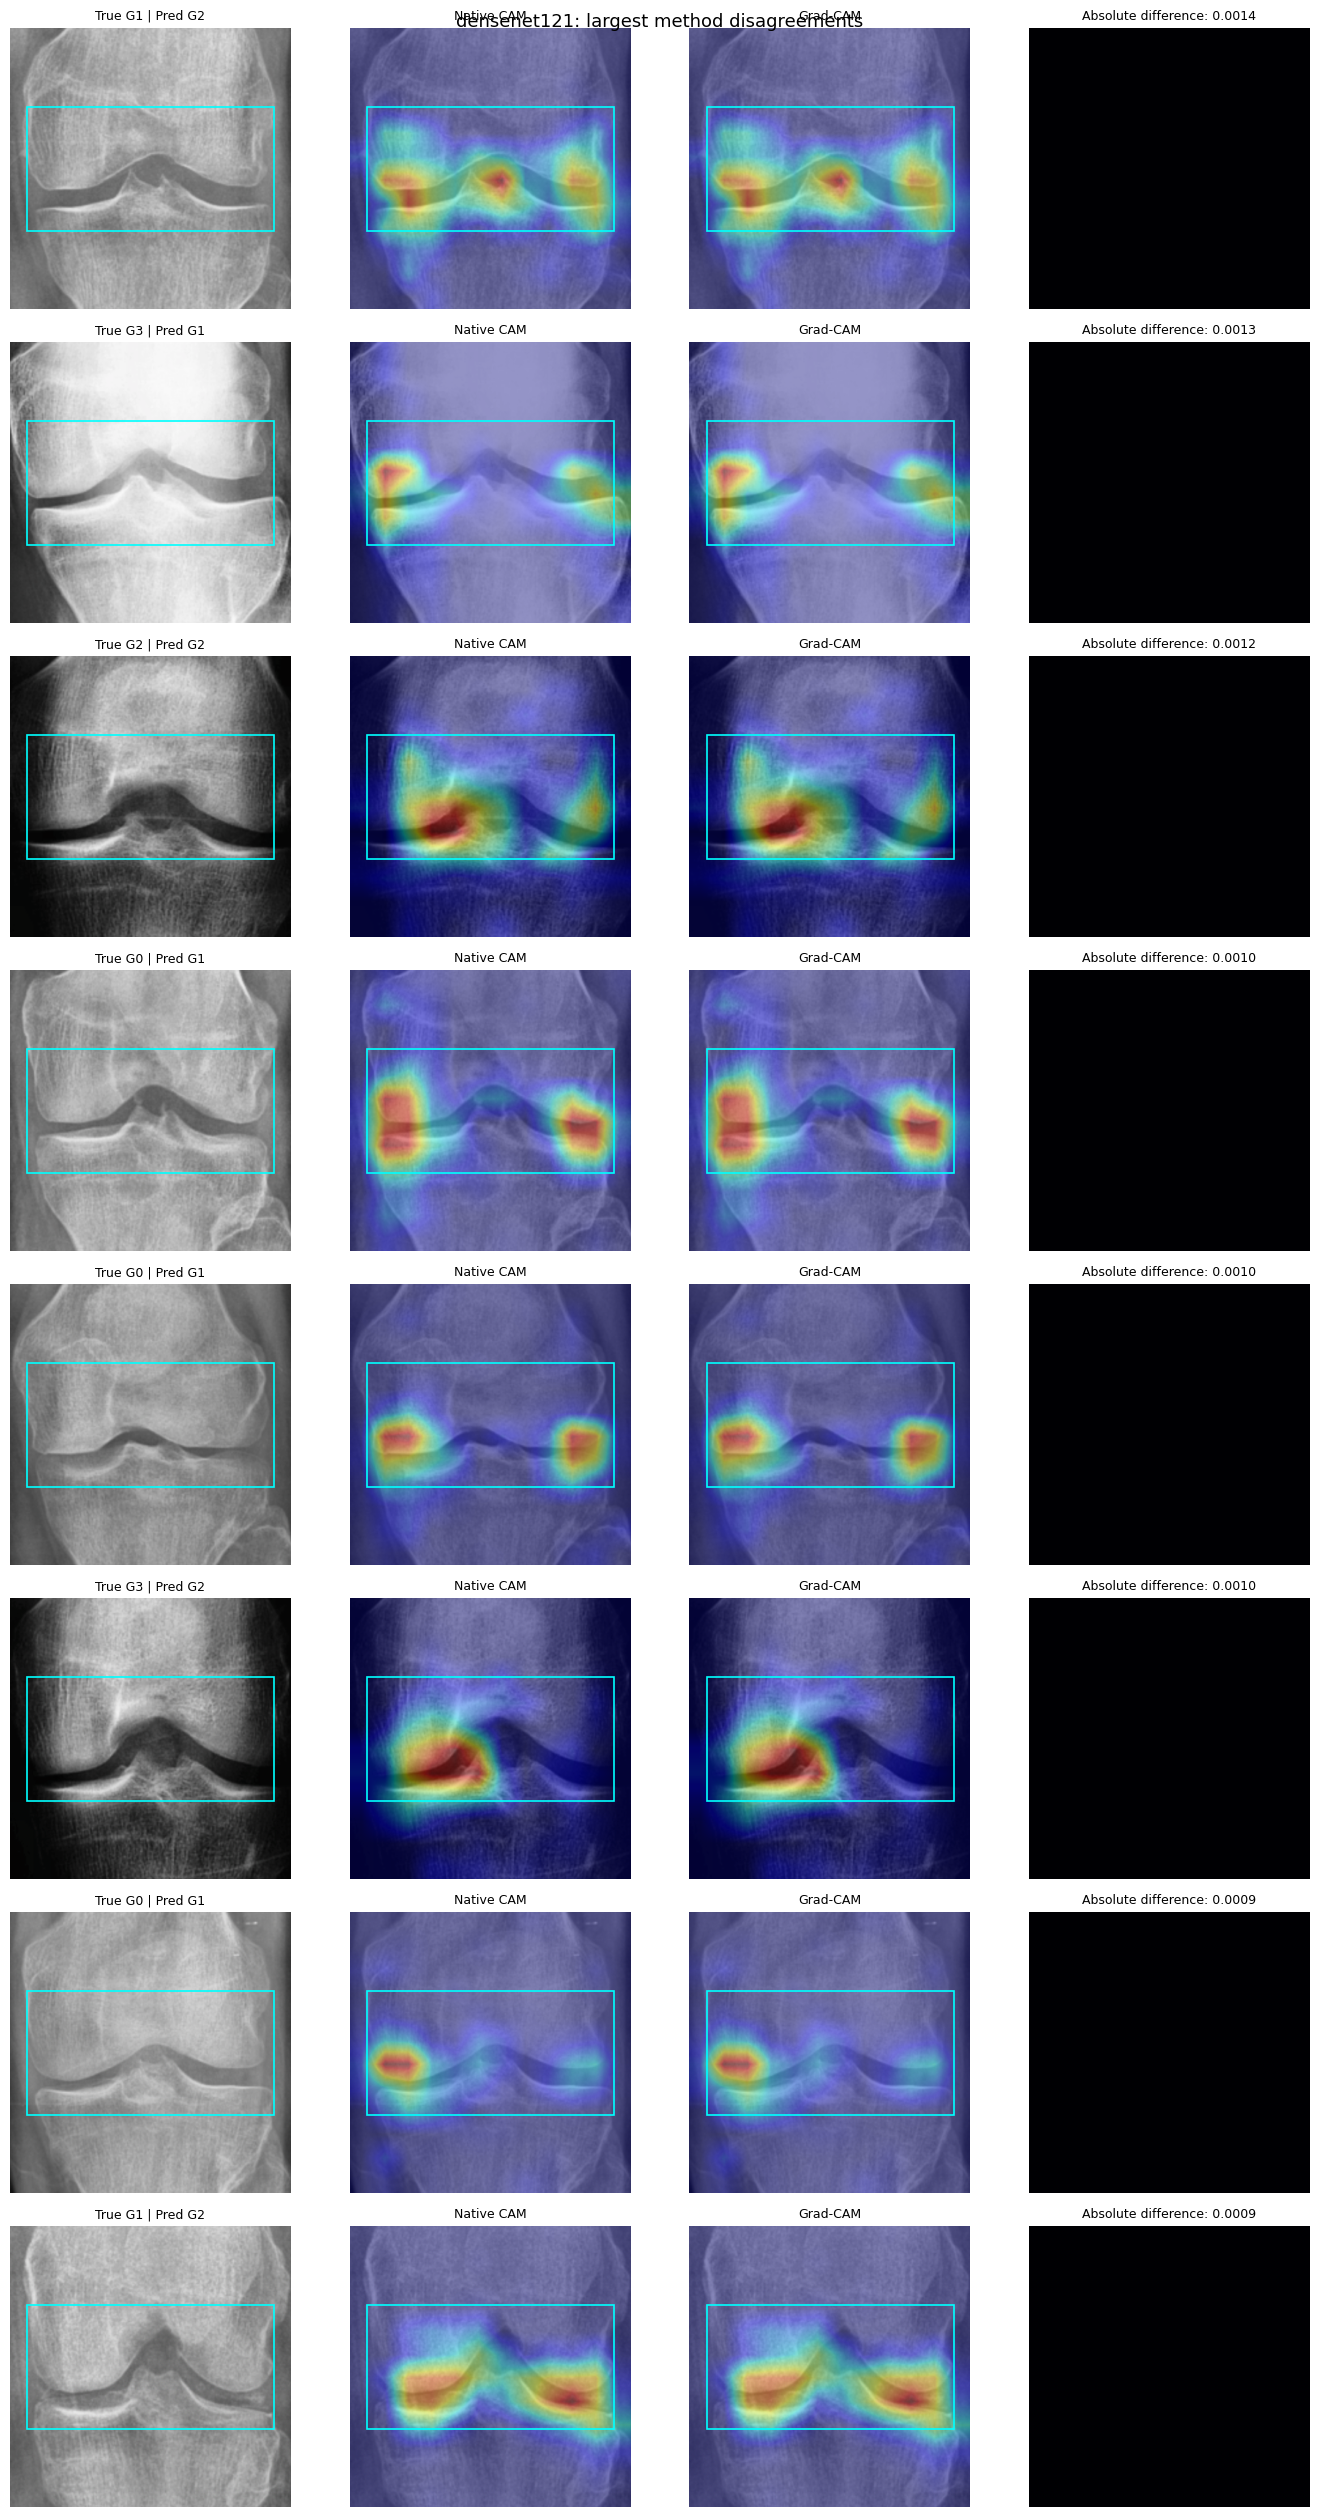

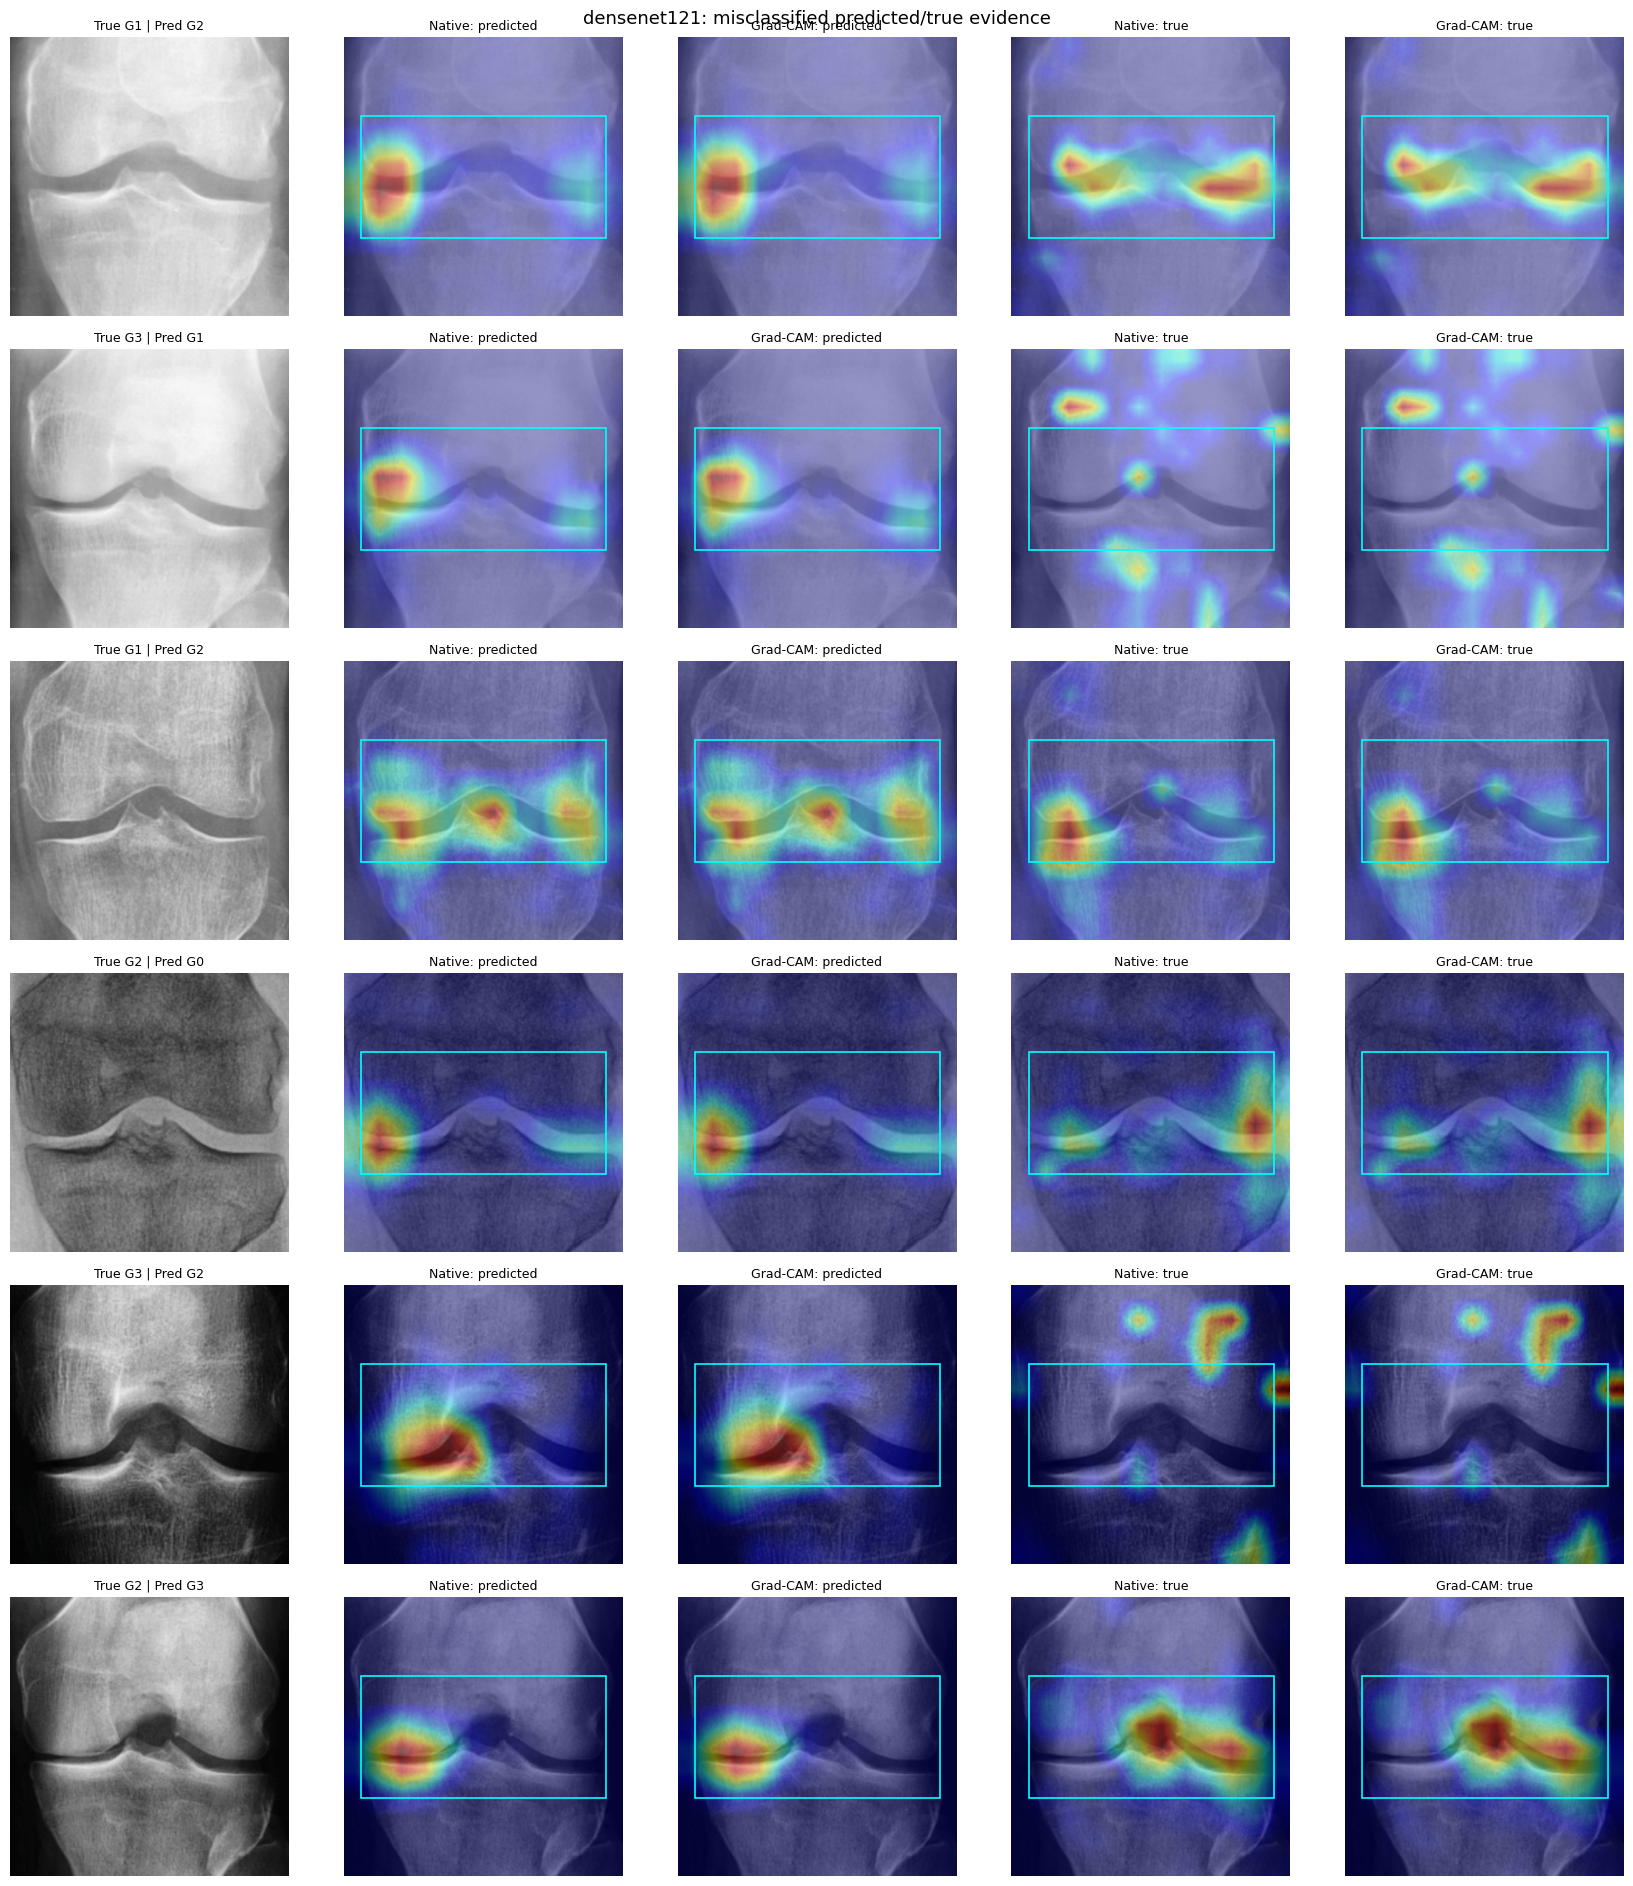

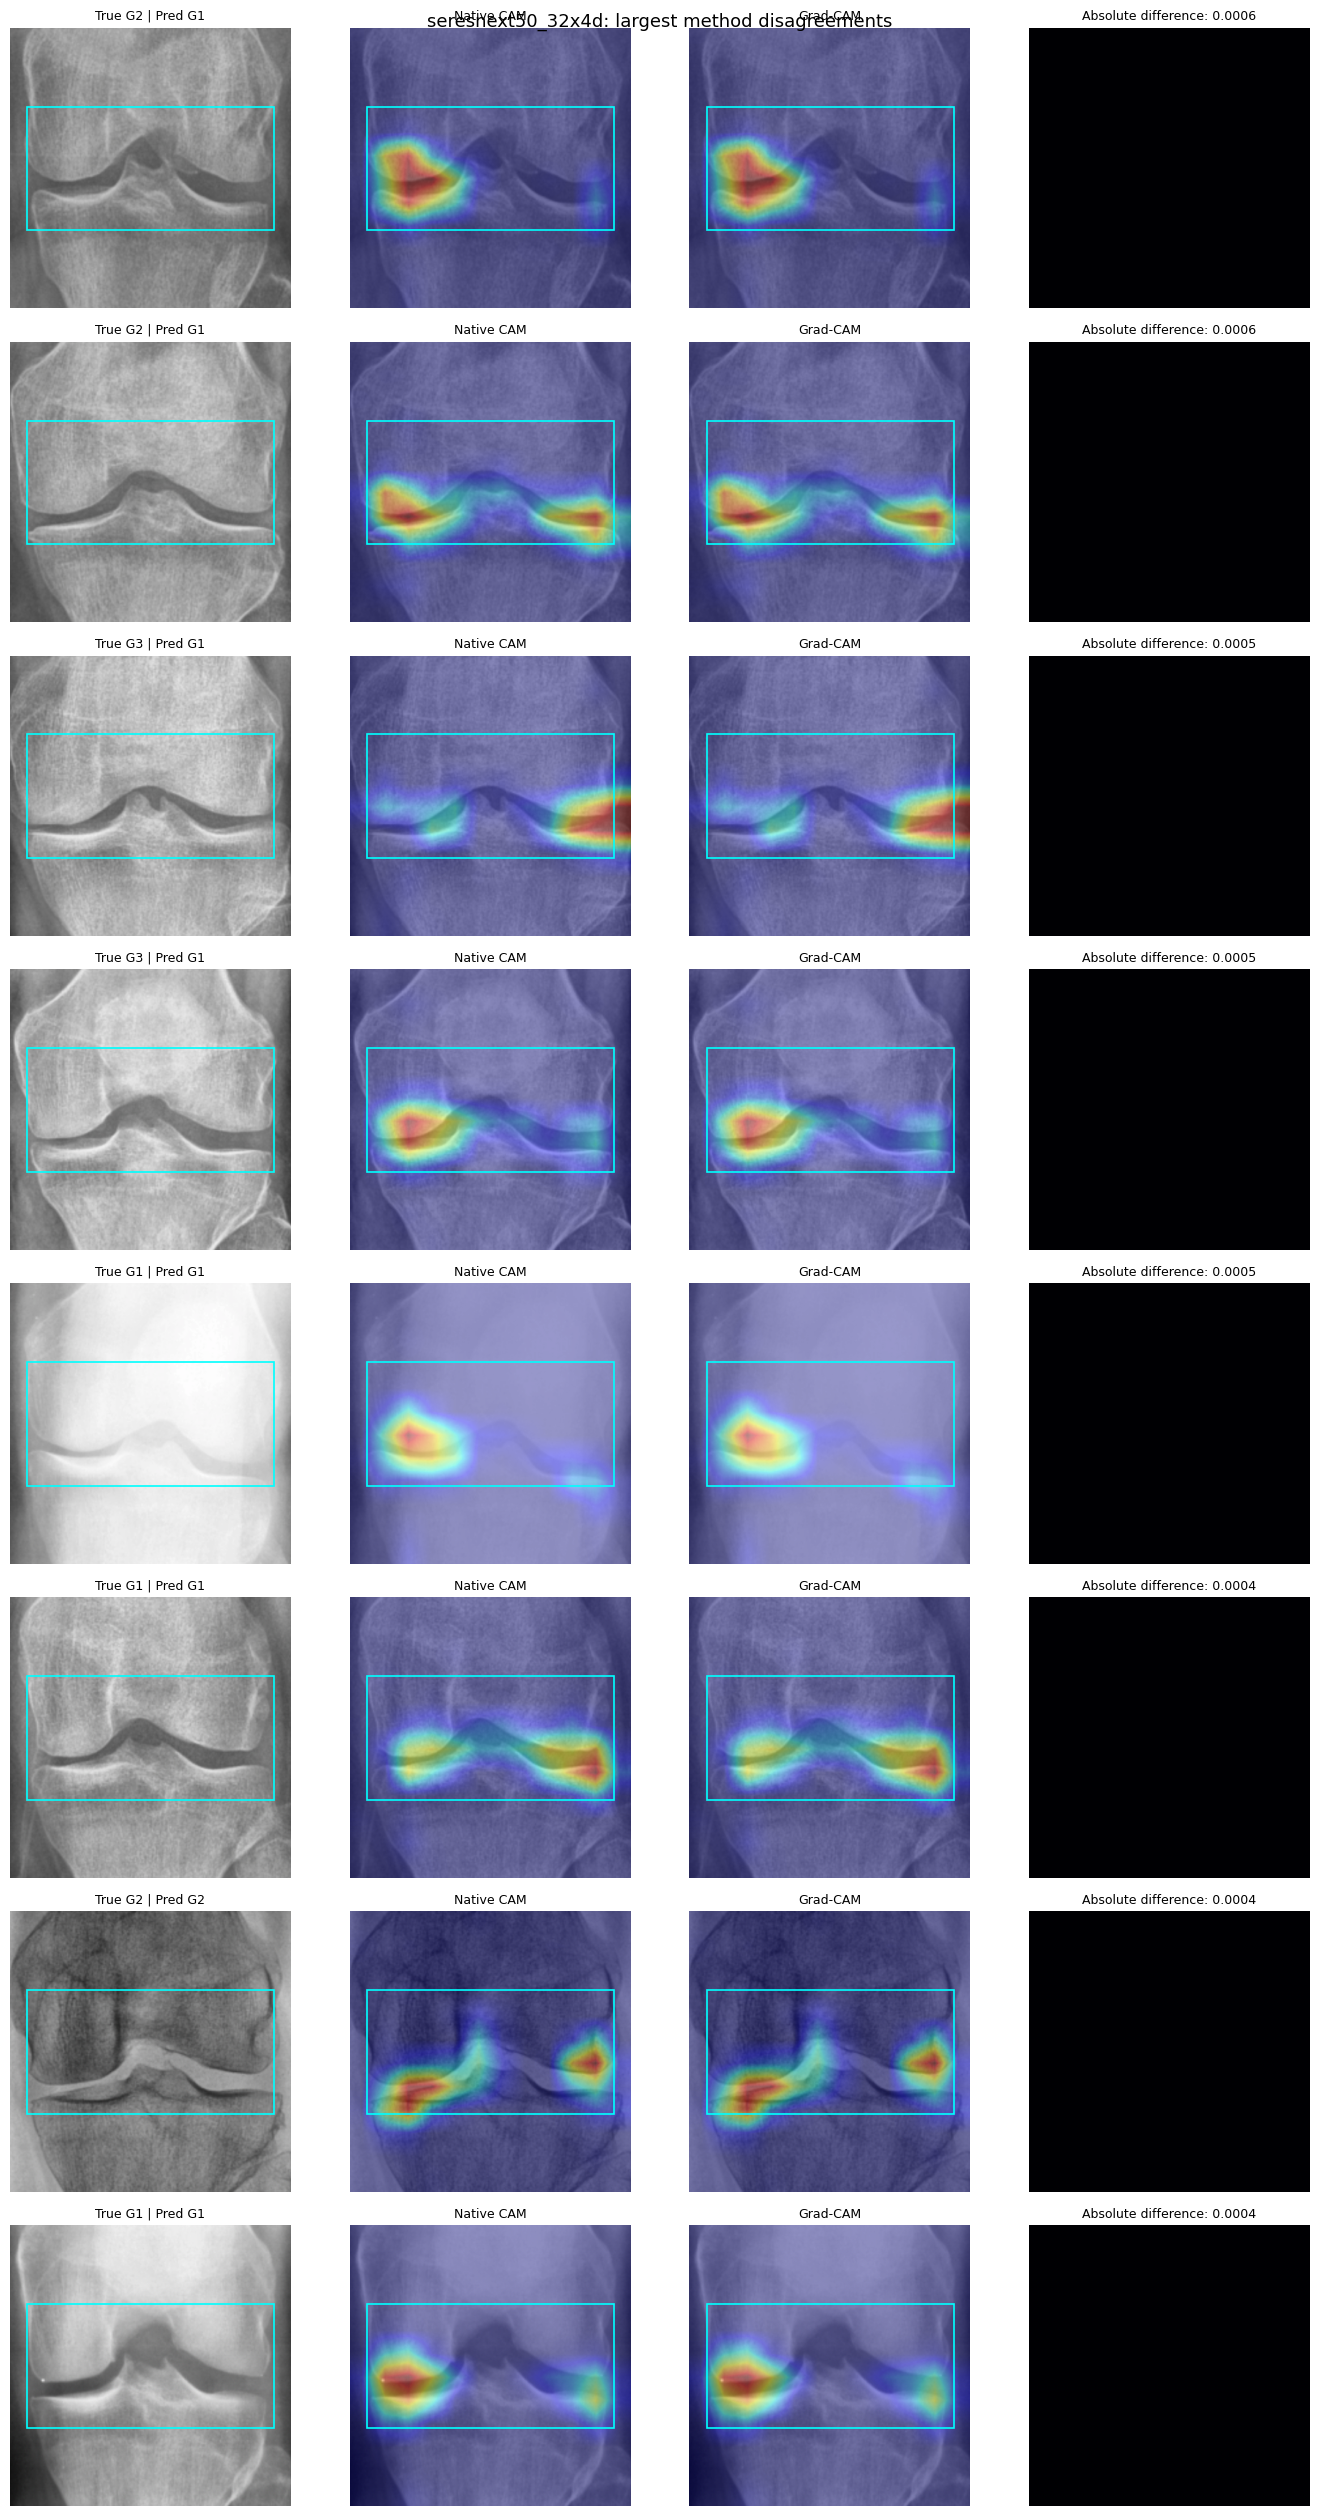

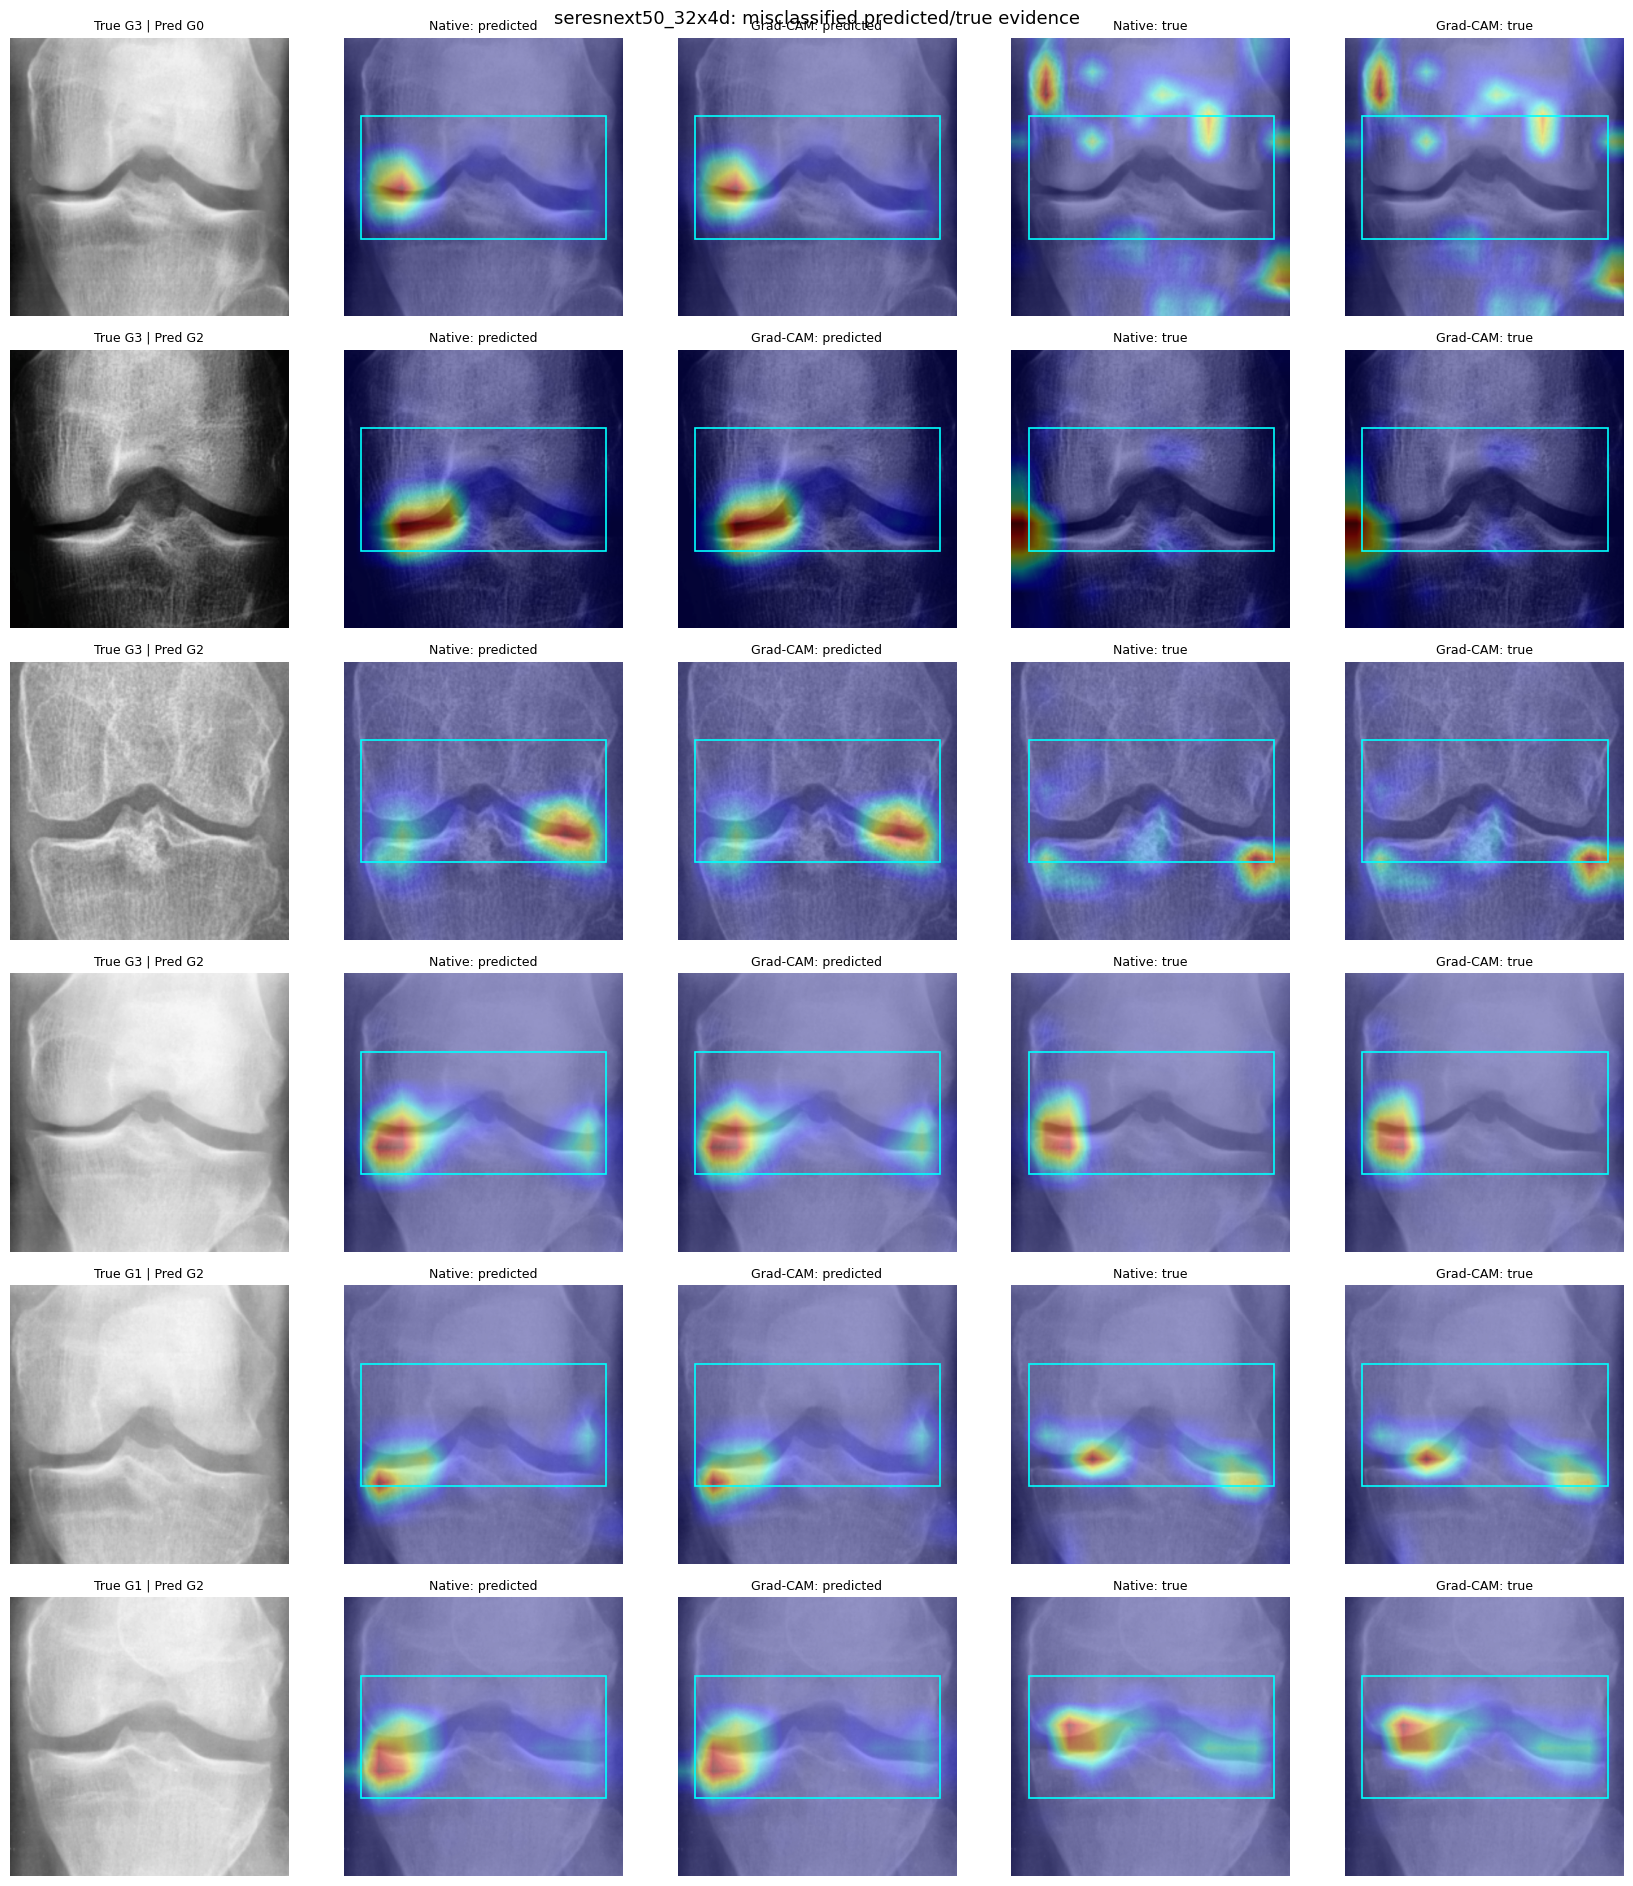

In [9]:
MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
STD = torch.tensor([0.229, 0.224, 0.225])[:, None, None]


def display_image(tensor):
    return (
        (tensor.cpu() * STD + MEAN)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )


def add_joint_rectangle(axis, height=384, width=384):
    from matplotlib.patches import Rectangle
    x0, x1 = 0.06 * width, 0.94 * width
    y0, y1 = 0.28 * height, 0.72 * height
    axis.add_patch(Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        fill=False, edgecolor="cyan", linewidth=1.2,
    ))


def overlay(axis, image, cam, title):
    axis.imshow(image)
    axis.imshow(cam, cmap="jet", alpha=0.40, vmin=0, vmax=1)
    add_joint_rectangle(axis, image.shape[0], image.shape[1])
    axis.set_title(title, fontsize=9)
    axis.axis("off")


for model_name in MODEL_SPECS:
    predicted = audit_frame[
        (audit_frame["model"] == model_name)
        & (audit_frame["target_kind"] == "predicted")
        & (audit_frame["method"] == "native_cam")
    ].sort_values("map_max_abs_difference", ascending=False).head(8)
    figure, axes = plt.subplots(len(predicted), 4, figsize=(14, 3.2 * len(predicted)))
    axes = np.atleast_2d(axes)
    for row_index, row in enumerate(predicted.itertuples()):
        tensor, native, gradcam = map_cache[
            (model_name, row.dataset_index, "predicted")
        ]
        image = display_image(tensor)
        axes[row_index, 0].imshow(image)
        add_joint_rectangle(axes[row_index, 0], image.shape[0], image.shape[1])
        axes[row_index, 0].set_title(
            f"True G{row.true_grade} | Pred G{row.predicted_grade}", fontsize=9
        )
        axes[row_index, 0].axis("off")
        overlay(axes[row_index, 1], image, native, "Native CAM")
        overlay(axes[row_index, 2], image, gradcam, "Grad-CAM")
        axes[row_index, 3].imshow(
            np.abs(native - gradcam), cmap="magma", vmin=0, vmax=1
        )
        axes[row_index, 3].set_title(
            f"Absolute difference: {row.map_max_abs_difference:.4f}", fontsize=9
        )
        axes[row_index, 3].axis("off")
    figure.suptitle(f"{model_name}: largest method disagreements", fontsize=13)
    figure.tight_layout()
    figure.savefig(
        RUN_DIR / f"{model_name}_native_vs_gradcam_disagreements.png", dpi=180
    )
    plt.show()

    errors = audit_frame[
        (audit_frame["model"] == model_name)
        & (audit_frame["target_kind"] == "true_on_error")
        & (audit_frame["method"] == "native_cam")
    ].sort_values("map_max_abs_difference", ascending=False).head(6)
    if errors.empty:
        continue
    figure, axes = plt.subplots(len(errors), 5, figsize=(17, 3.2 * len(errors)))
    axes = np.atleast_2d(axes)
    for row_index, row in enumerate(errors.itertuples()):
        tensor, native_pred, gradcam_pred = map_cache[
            (model_name, row.dataset_index, "predicted")
        ]
        _, native_true, gradcam_true = map_cache[
            (model_name, row.dataset_index, "true_on_error")
        ]
        image = display_image(tensor)
        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(
            f"True G{row.true_grade} | Pred G{row.predicted_grade}", fontsize=9
        )
        axes[row_index, 0].axis("off")
        overlay(axes[row_index, 1], image, native_pred, "Native: predicted")
        overlay(axes[row_index, 2], image, gradcam_pred, "Grad-CAM: predicted")
        overlay(axes[row_index, 3], image, native_true, "Native: true")
        overlay(axes[row_index, 4], image, gradcam_true, "Grad-CAM: true")
    figure.suptitle(f"{model_name}: misclassified predicted/true evidence", fontsize=13)
    figure.tight_layout()
    figure.savefig(
        RUN_DIR / f"{model_name}_misclassified_predicted_true_cams.png", dpi=180
    )
    plt.show()


## Reproducible Report

The generated report distinguishes operational preference from demonstrated
localization superiority. Native CAM remains simpler and faster because it requires
no backward pass, but that alone is not evidence that its localization is better.


In [10]:
summary_records = json.loads(summary_frame.to_json(orient="records"))
bootstrap_records = json.loads(bootstrap_frame.to_json(orient="records"))
decision_records = json.loads(decision_frame.to_json(orient="records"))

manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "dataset_split": "validation_only",
    "audit_per_grade": AUDIT_PER_GRADE,
    "audited_indices": audit_indices,
    "occlusion_grid": OCCLUSION_GRID,
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "equivalence_max_abs_tolerance": EQUIVALENCE_MAX_ABS_TOLERANCE,
    "checkpoint_manifest": checkpoint_manifest,
    "summary": summary_records,
    "paired_bootstrap": bootstrap_records,
    "decisions": decision_records,
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)


def markdown_table(frame, columns, precision=4):
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    lines = [header, separator]
    for _, row in frame[columns].iterrows():
        values = []
        for value in row:
            if isinstance(value, (float, np.floating)):
                values.append(f"{value:.{precision}f}")
            else:
                values.append(str(value))
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


report_summary = summary_frame.rename(columns={
    "model": "Model",
    "method": "Method",
    "joint_energy": "Joint energy",
    "border_energy": "Border energy",
    "lower_tibia_energy": "Lower-tibia energy",
    "peak_inside_joint": "Peak inside",
    "anatomy_score": "Anatomy score",
    "occlusion_correlation": "Occlusion correlation",
    "top_cam_confidence_drop": "Top-CAM drop",
})
report_decisions = decision_frame.rename(columns={
    "model": "Model",
    "decision": "Statistical decision",
    "maps_equivalent_at_tolerance": "Equivalent",
    "maximum_pixel_difference": "Maximum pixel difference",
})

report = f'''# Grad-CAM vs Native-CAM: Two-Model Controlled Comparison

| Field | Value |
| --- | --- |
| Exact UTC run timestamp | {RUN_TIMESTAMP} |
| Data | Validation only; test was not read |
| Models | DenseNet-121, SE-ResNeXt50-32x4d |
| Audit size | Up to {AUDIT_PER_GRADE} images per KL grade |
| Occlusion grid | {OCCLUSION_GRID}x{OCCLUSION_GRID} |
| Paired bootstrap repetitions | {BOOTSTRAP_REPETITIONS} |

## Predicted-Class Summary

{markdown_table(report_summary, [
    "Model", "Method", "Joint energy", "Border energy",
    "Lower-tibia energy", "Peak inside", "Anatomy score",
    "Occlusion correlation", "Top-CAM drop",
])}

## Fixed Statistical Decision

{markdown_table(report_decisions, [
    "Model", "Statistical decision", "Equivalent", "Maximum pixel difference",
], precision=6)}

## Interpretation

The same classifier checkpoint produces both methods, so classification QWK, AP,
precision, recall, and F1 are identical and are not method-comparison outcomes.
Native CAM is operationally cheaper because it needs one forward pass and no
gradient computation. It is considered more anatomically or causally faithful only
when the predeclared paired localization and occlusion decision rule supports it.

For this linear class-map architecture, final-layer Grad-CAM is analytically the
bias-free form of native CAM. Any remaining difference should be explained by the
learned class bias, ReLU, normalization, or an implementation error. The recorded
gradient-weight error and bias-free-CAM pixel difference test the Grad-CAM
implementation directly. Native CAM is not declared better merely because it is
gradient-free or exactly reconstructs the logits.
'''
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(report)
print(f"All comparison artifacts: {RUN_DIR}")


# Grad-CAM vs Native-CAM: Two-Model Controlled Comparison

| Field | Value |
| --- | --- |
| Exact UTC run timestamp | 2026-07-24_01-12-36_714882_UTC |
| Data | Validation only; test was not read |
| Models | DenseNet-121, SE-ResNeXt50-32x4d |
| Audit size | Up to 50 images per KL grade |
| Occlusion grid | 4x4 |
| Paired bootstrap repetitions | 2000 |

## Predicted-Class Summary

| Model | Method | Joint energy | Border energy | Lower-tibia energy | Peak inside | Anatomy score | Occlusion correlation | Top-CAM drop |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| densenet121 | native_cam | 0.7997 | 0.1308 | 0.1014 | 1.0000 | 0.5675 | 0.7109 | 0.2095 |
| densenet121 | gradcam | 0.7992 | 0.1310 | 0.1017 | 1.0000 | 0.5665 | 0.7110 | 0.2095 |
| seresnext50_32x4d | native_cam | 0.8690 | 0.0769 | 0.0879 | 0.9956 | 0.7042 | 0.6528 | 0.1839 |
| seresnext50_32x4d | gradcam | 0.8692 | 0.0768 | 0.0879 | 0.9956 | 0.7045 | 0.6528 | 0.1839 |

## Fixed Statistical Decision

| Model | Stat

In [11]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
